# Titanic Exercise

to install seaborn :
```bash
conda install -c conda-forge seaborn
````


In [1]:
import pandas as pd
from seaborn import load_dataset
import matplotlib.pyplot as plt
import numpy as np

In [2]:
embarked_labels = {
  "C": "Cherbourg",
  "Q": "Queenstown",
  "S": "Southampton",
}

In [3]:
# 1. Load the dataset
titanic: pd.DataFrame = load_dataset("titanic")
titanic


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
titanic.info()
titanic.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# 2. Data cleaning
# 2.1. Check the missing values
print(titanic.shape)
print(titanic.isnull().sum())

# 2.2. Replace the missing values in age with the mean
# titanic["age"] = titanic["age"].fillna(titanic["age"].mean())
# titanic["age"] = titanic["age"].map(lambda age: titanic["age"].mean() if pd.isnull(age) else age)
titanic.fillna({"age": np.ceil(titanic["age"].mean())}, inplace=True)

# 2.3 rop unused columns
# titanic.drop("deck", axis=1, inplace=True)
titanic.drop(columns=["deck", "who", "embark_town", "class", "alive"], inplace=True)

# 2.4 drop the rows with missing values in embarked
titanic.dropna(subset=["embarked"], inplace=True)

# 2.5 Transform month age to 1 year
titanic.age = titanic.age.map(lambda age: 1 if age < 1 else age)


print(titanic.shape)
print(titanic.isnull().sum())

(891, 15)
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
(889, 10)
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
alone         0
dtype: int64


In [ ]:
# 3 Analyse data
# 3.1 Calculer le taux global de survie des passagers du Titanic.
survival_rate: float = titanic.survived.sum() / titanic.survived.count()
survival_rate: float = titanic.survived.mean()
survival_rate: float = titanic.loc[titanic.survived == 1].shape[0] / titanic.survived.count()
survival_rate

np.float64(0.38245219347581555)

In [36]:
# 3.2 Analyser la répartition des passagers par classe (Pclass) et par port d'embarquement (Embarked).
# pc_class_count = titanic.pclass.value_counts().sort_index()
# pc_class_count

# titanic.groupby(["embarked", "pclass"]).size().unstack()
# titanic.groupby("embarked").pclass.value_counts(normalize=True).unstack()
# pd.crosstab(titanic.embarked, titanic.pclass)
titanic.groupby(["embarked", "pclass"]).survived.count().reset_index().pivot(index="embarked", columns="pclass", values="survived")


pclass,1,2,3
embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353


In [46]:
# 3.3 Calculer la proportion de passagers masculins et féminins.

gender_proportion: pd.Series = titanic.sex.value_counts(normalize=True)
gender_proportion

sex
male      0.649044
female    0.350956
Name: proportion, dtype: float64

age
1.0     14
2.0     10
3.0      6
4.0     10
5.0      4
        ..
70.0     2
70.5     1
71.0     2
74.0     1
80.0     1
Name: count, Length: 83, dtype: int64

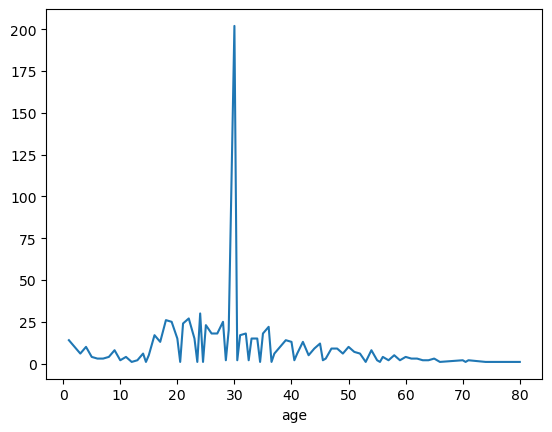

<Axes: xlabel='age_category'>

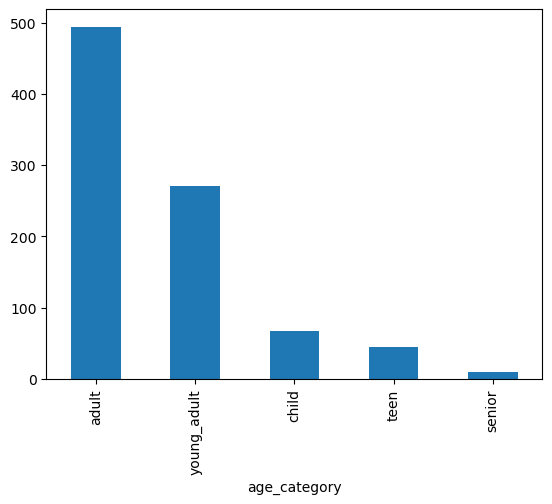

In [71]:
# 3.4 Identifier la distribution d'âge des passagers et trouver les catégories d'âge les plus représentées. (look pd.cut() function with bins)

std_age = titanic.age.value_counts().sort_index()
display(std_age)
std_age.plot()
plt.show()

# labels: list[str] = [f"{i}-{i+9}" for i in range(0, 80, 10)]
# bins: list[int] = list(range(0, 81, 10))

# print(labels, bins)
# age_category: pd.Series = pd.cut(titanic.age, bins=bins, labels=labels, right=False)
# age_category.value_counts().sort_index().plot(kind="bar")

labels: list[str] = ["child", "teen", "young_adult", "adult", "senior"]
bins: list[int] = [0, 12, 18, 30, 65, 80]
age_category: pd.Series = pd.cut(titanic.age, bins=bins, labels=labels, right=False)
titanic["age_category"] = age_category
titanic["age_category"].value_counts().plot(kind="bar")

<Axes: xlabel='pclass'>

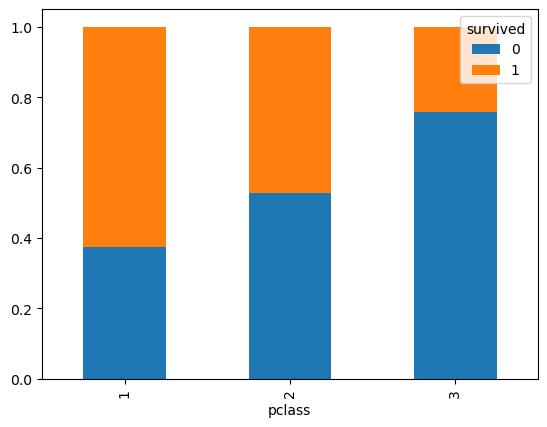

In [80]:
# 4 Alives analyse
# 4.1 Analyser la survie en fonction de la classe des billets (Pclass).
# titanic.groupby("pclass").survived.mean()
titanic.groupby("pclass").survived.value_counts(normalize=True).unstack().plot(kind="bar", stacked=True)

<Axes: xlabel='sex'>

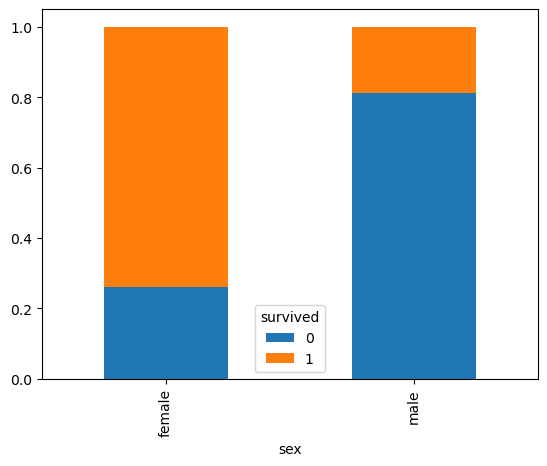

In [84]:
# 4.2 Examiner la survie en fonction du genre (Sex) des passagers.

titanic.groupby("sex").survived.value_counts(normalize=True).unstack()
titanic.groupby("sex").survived.value_counts(normalize=True).unstack().plot.bar(stacked=True)

<Axes: xlabel='pclass,sex'>

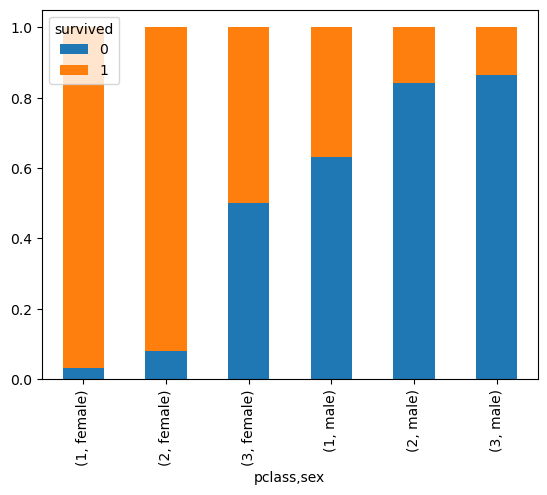

In [88]:
# (BONUS)
titanic.groupby(["pclass", "sex"]).survived\
.value_counts(normalize=True).unstack()\
.sort_index(level=[1])\
.plot.bar(stacked=True)

In [89]:
# (BONUS)
titanic.groupby(["age_category", "pclass", "sex"]).survived\
.value_counts(normalize=True).unstack()
# .sort_index(level=[1])\
# .plot.bar(stacked=True)

survived                           0         1
age_category pclass sex                       
child        1      female  1.000000       NaN
                    male         NaN  1.000000
             2      female       NaN  1.000000
                    male         NaN  1.000000
             3      female  0.521739  0.478261
                    male    0.666667  0.333333
teen         1      female       NaN  1.000000
                    male         NaN  1.000000
             2      female       NaN  1.000000
                    male    1.000000       NaN
             3      female  0.333333  0.666667
                    male    0.894737  0.105263
young_adult  1      female  0.045455  0.954545
                    male    0.571429  0.428571
             2      female  0.103448  0.896552
                    male    0.972222  0.027778
             3      female  0.512195  0.487805
                    male    0.852459  0.147541
adult        1      female  0.016129  0.983871
                    male    0.659341  0.340659
             2      female  0.085714  0.914286
                    male    0.881356  0.118644
             3      female  0.514706  0.485294
                    male    0.893855  0.106145
senior       1      male    1.000000       NaN
             2      male    1.000000       NaN
             3      male    1.000000       NaN

In [92]:
# 4.3 Étudier la survie en fonction de l'âge (Age) des passagers.
titanic.groupby("age_category").survived.value_counts(normalize=True).sort_index().unstack()

survived,0,1
age_category,,
child,0.426471,0.573529
teen,0.511111,0.488889
young_adult,0.649446,0.350554
adult,0.629555,0.370445
senior,1.000000,NaN


In [95]:
# 4.4 Analyser la survie en fonction du port d'embarquement (Embarked).
titanic.groupby("embarked").survived.value_counts(normalize=True).unstack()

survived,0,1
embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


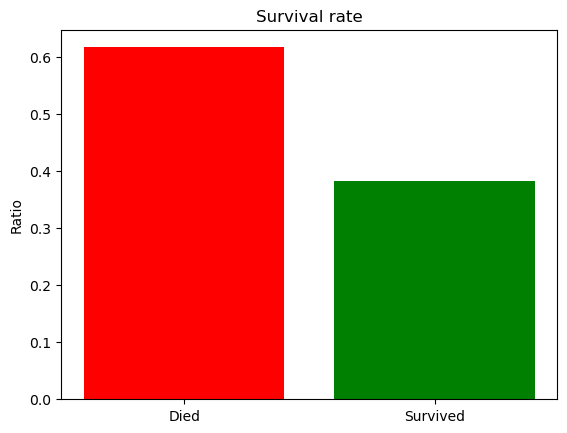

In [98]:
# 5 Plottings
# 5.1 Créer un diagramme à barres (plt.bar) pour visualiser le taux de survie global.

plt.bar(["Died", "Survived"], [1-survival_rate, survival_rate], color=["r", "g"])
plt.title("Survival rate")
plt.ylabel("Ratio")

plt.show()

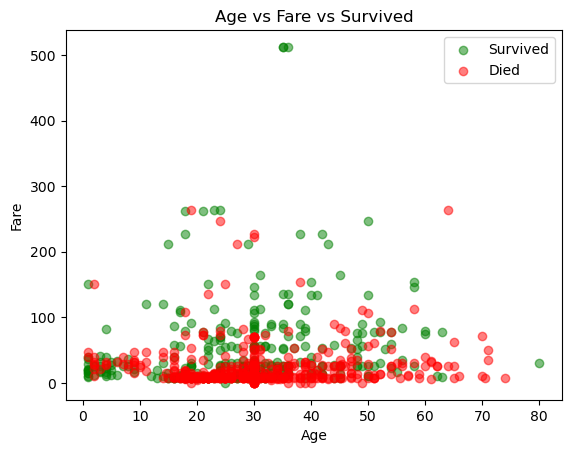

In [ ]:
# 5.2 Créer un nuage de points (plt.scatter) pour représenter la relation entre l'âge (Age) et le prix du billet (Fare) en fonction de la survie.

plt.scatter(
  titanic.loc[titanic.survived == 1].age,
  titanic.loc[titanic.survived == 1].fare,
  c="g", alpha=0.5, label="Survived"
)
plt.scatter(
  titanic.loc[titanic.survived == 0].age,
  titanic.loc[titanic.survived == 0].fare,
  c="r", alpha=0.5, label="Died"
)


plt.title("Age vs Fare vs Survived")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend()

plt.show()

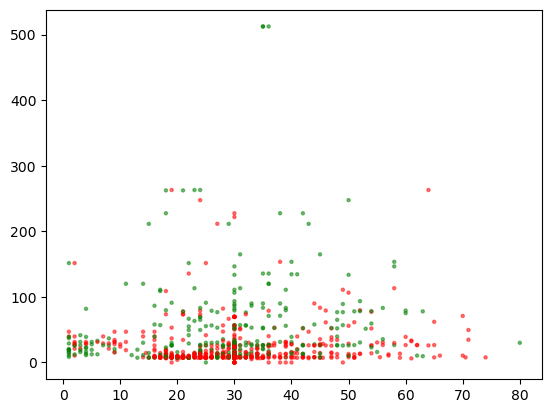

In [113]:
plt.scatter(
  titanic.age, titanic.fare, 
  c=titanic.survived.map(lambda s: ["r", "g"][s]),
  alpha=0.5, s=5
)

plt.show()

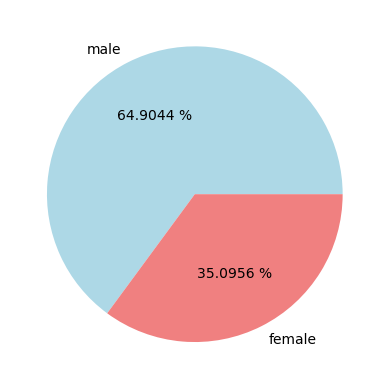

In [125]:
# 5.3 Produire un diagramme circulaire (Pie chart) pour montrer la proportion de passagers masculins et féminins.

plt.pie(gender_proportion, labels=gender_proportion.index, autopct="%.4f %%", colors=["lightblue", "Lightcoral"])
plt.show()

embarked,C,Q,S
pclass,,,
1,85,2,127
2,17,3,164
3,66,72,353


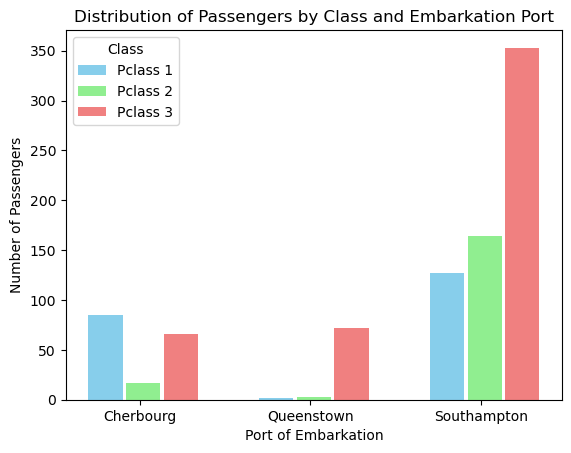

In [127]:
# 5.4 Générer un graphique en barres (plt.bar) pour montrer la répartition des passagers par classe (Pclass) et par port d'embarquement (Embarked).

distribution_by_class_embarked = titanic.groupby(['pclass', 'embarked']).size().unstack()
display(distribution_by_class_embarked)

fig, ax = plt.subplots()
width = 0.2
class_labels: list[str] = distribution_by_class_embarked.columns.map(embarked_labels.get)
enu: list[tuple[int, tuple[int, str]]] = enumerate(zip(distribution_by_class_embarked.index, ["skyblue", "lightgreen", "lightcoral"]))
for i, (pclass, color) in enu:
  positions: list[int|float] = list(range(len(class_labels))) if i==0 else [pos + width + 0.02 for pos in positions]
  plt.bar(positions, distribution_by_class_embarked.loc[pclass], width=width, label=f'Pclass {pclass}', color=color)

# Adding labels and title
plt.title('Distribution of Passengers by Class and Embarkation Port')
plt.xlabel('Port of Embarkation')
plt.ylabel('Number of Passengers')
plt.xticks([pos + width for pos in range(len(class_labels))], class_labels)
plt.legend(title='Class')

# Show the plot
plt.show()

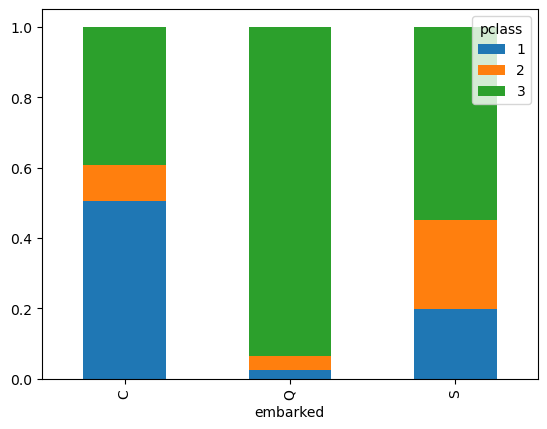

In [142]:
# distribution_by_class_embarked.T.plot.bar()
titanic.groupby(['embarked']).pclass.value_counts(normalize=True).unstack().plot.bar(stacked=True)
# plt.plot(["C", "Q", "S"], [0.5, 0.3, 0.8])
plt.show()

,age,fare,pclass,sibsp,parch,gender,survived
age,1.000000,0.087672,0.326414,0.231724,0.179292,0.089985,0.075337
fare,0.087672,1.000000,0.548193,0.160887,0.217532,0.179958,0.255290
pclass,0.326414,0.548193,1.000000,0.081656,0.016824,0.127741,0.335549
sibsp,0.231724,0.160887,0.081656,1.000000,0.414542,0.116348,0.034040
parch,0.179292,0.217532,0.016824,0.414542,1.000000,0.247508,0.083151
gender,0.089985,0.179958,0.127741,0.116348,0.247508,1.000000,0.541585
survived,0.075337,0.255290,0.335549,0.034040,0.083151,0.541585,1.000000


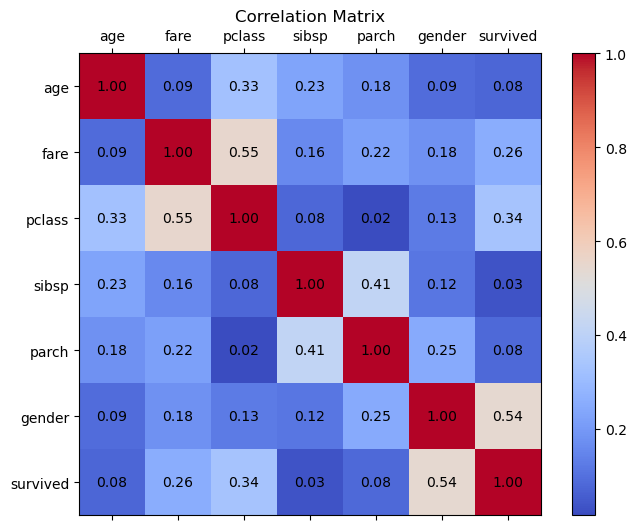

In [140]:
# 6 Bonus for the datascients experts ;P

import numpy as np
# 6 Bonus for the datascients experts ;P
# Examiner la corrélation entre les différentes caractéristiques des passagers pour identifier les relations significatives.
correlation_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'gender', 'survived']
titanic["gender"] = titanic.sex.map({"male": 0, "female": 1})

correlation_matrix = (titanic[correlation_columns].corr()**2)**(1/2)
display(correlation_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(correlation_matrix, cmap="coolwarm")
fig.colorbar(cax)

# set labels
ax.set_xticks(list(range(len(correlation_columns))))
ax.set_yticks(list(range(len(correlation_columns))))
ax.set_xticklabels(correlation_columns)
ax.set_yticklabels(correlation_columns)

# Display correlation coefficient
for i in range(len(correlation_columns)):
  for j in range(len(correlation_columns)):
    text = ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")
  
plt.title("Correlation Matrix")

plt.show()


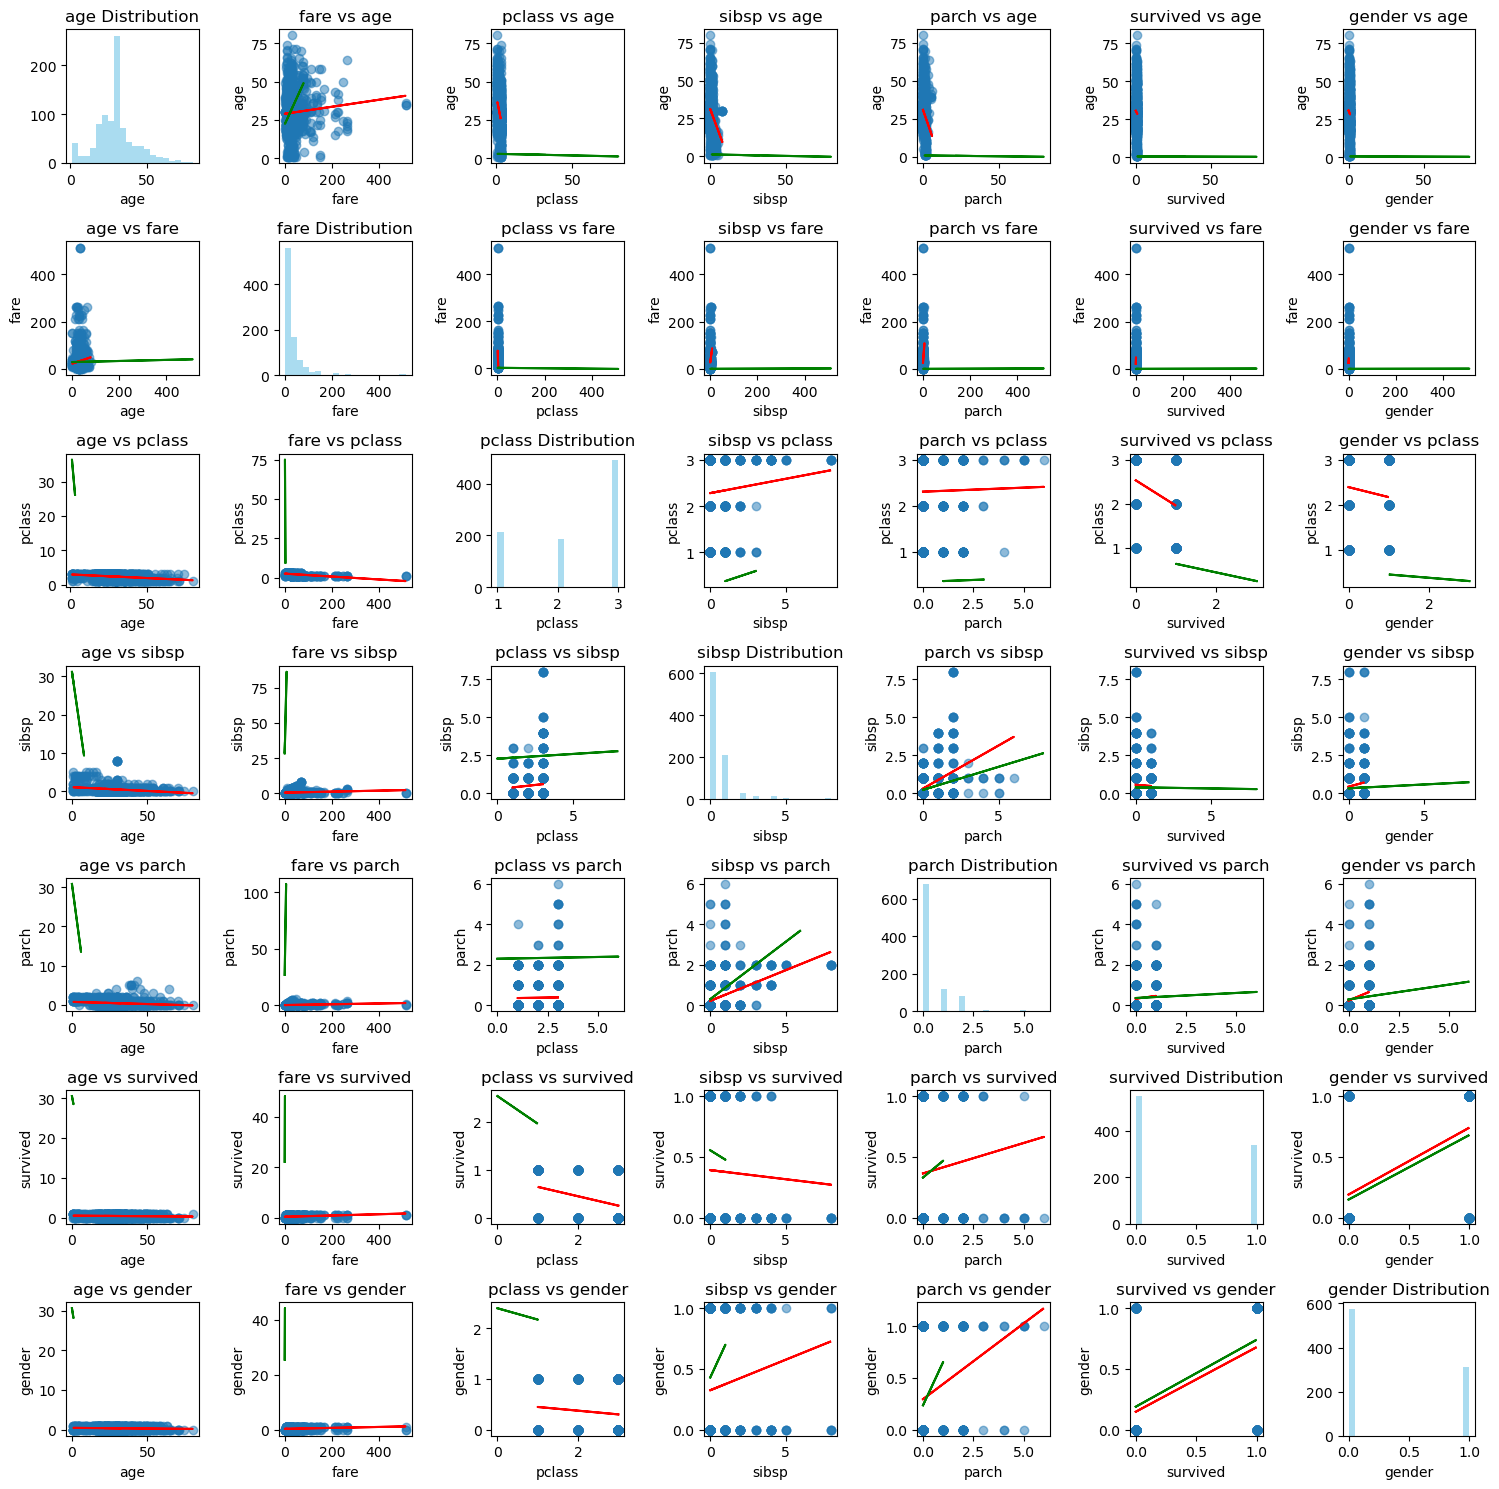

In [141]:
import numpy as np

# Select relevant numerical columns
numerical_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived', 'gender']

# Create a matrix of scatter plots
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=len(numerical_columns), figsize=(15, 15))

for i in range(len(numerical_columns)):
    for j in range(len(numerical_columns)):
        if i == j:
            axes[i, j].hist(titanic[numerical_columns[i]], bins=20, color='skyblue', alpha=0.7)
            axes[i, j].set_title(f'{numerical_columns[i]} Distribution')
            axes[i, j].set_xlabel(numerical_columns[i])
        else:
            axes[i, j].scatter(titanic[numerical_columns[j]], titanic[numerical_columns[i]], alpha=0.5)
            axes[i, j].set_title(f'{numerical_columns[j]} vs {numerical_columns[i]}')
            axes[i, j].set_xlabel(numerical_columns[j])
            axes[i, j].set_ylabel(numerical_columns[i])
            a, b = np.polyfit(titanic[numerical_columns[j]], titanic[numerical_columns[i]], 1)
            axes[i, j].plot(titanic[numerical_columns[j]], a*titanic[numerical_columns[j]]+b, c="r")
            a, b = np.polyfit(titanic[numerical_columns[i]], titanic[numerical_columns[j]], 1)
            axes[i, j].plot(titanic[numerical_columns[i]], a*titanic[numerical_columns[i]]+b, c="g")

# Adjust layout
plt.tight_layout()
plt.show()